<a href="https://colab.research.google.com/github/tamara-kostova/MSc_Thesis_Neuroimaging/blob/master/13_SAM3_Tumor_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Evaluate SAM3 on tumor annotated data set
Brain Tumor Segmentation 2020 Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Download dataset
https://www.kaggle.com/datasets/awsaf49/brats20-dataset-training-validation

In [ ]:
from google.colab import userdata
import os
os.environ["KAGGLE_KEY"] = userdata.get('KAGGLE_KEY')
os.environ["KAGGLE_USERNAME"] = userdata.get('KAGGLE_USERNAME')

In [ ]:
!kaggle datasets download -d awsaf49/brats20-dataset-training-validation -p "/content/drive/MyDrive/SAM 3/tumor" --unzip

Dataset URL: https://www.kaggle.com/datasets/awsaf49/brats20-dataset-training-validation
License(s): CC0-1.0
100% 4.15G/4.16G [00:29<00:00, 143MB/s]
100% 4.16G/4.16G [00:29<00:00, 152MB/s]


In [ ]:
import numpy as np
import nibabel as nib
from PIL import Image
from pathlib import Path
import pandas as pd
from tqdm import tqdm
import torch
import gc

import matplotlib.pyplot as plt
import matplotlib.patches as patches

## Helpers

In [ ]:
def load_brats20_case(case_dir):
    """Load BraTS20 - handles both .nii and .nii.gz files."""

    # Try both extensions
    files = list(case_dir.glob("*.nii.gz")) + list(case_dir.glob("*.nii"))

    t1ce = seg = None

    for f in files:
        name_lower = f.name.lower()

        if 'seg' in name_lower:
            seg = nib.load(f).get_fdata()
        elif 't1ce' in name_lower:
            t1ce = nib.load(f).get_fdata()

    return t1ce, seg

In [ ]:
def normalize_mri(img):
    img_min, img_max = img.min(), img.max()
    return (img - img_min) / (img_max - img_min + 1e-8)

In [ ]:
def compute_metrics(pred, gt):
    """Calculate segmentation metrics."""
    pred_flat = pred.flatten() > 0.5
    gt_flat = gt.flatten() > 0.5
    tp = np.sum(pred_flat & gt_flat)
    fp = np.sum(pred_flat & ~gt_flat)
    fn = np.sum(~pred_flat & gt_flat)
    dice = 2 * tp / (2 * tp + fp + fn) if (2*tp + fp + fn) > 0 else 0
    iou = tp / (tp + fp + fn) if (tp + fp + fn) > 0 else 0
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0
    return {'dice': dice, 'iou': iou, 'sensitivity': sens, 'tp': tp, 'fp': fp, 'fn': fn}

In [ ]:
def safe_sam3_inference(processor, img, prompt):
    """Safe SAM3 inference with correct API."""
    try:
        if img.mode != 'RGB':
            img = img.convert('RGB')

        inference_state = processor.set_image(img)

        output = processor.set_text_prompt(prompt, inference_state)

        masks = output.get("masks", torch.tensor([]))
        scores = output.get("scores", torch.tensor([]))

        if len(masks) == 0 or len(scores) == 0:
            return None, 0.0, 0

        best_idx = torch.argmax(scores)
        best_mask = masks[best_idx].cpu().numpy().squeeze()
        best_score = scores[best_idx].item()

        torch.cuda.empty_cache()

        return best_mask, best_score, len(masks)
    except Exception as e:
        print(f"    ⚠️  SAM3 error: {e}")
        torch.cuda.empty_cache()
        return None, 0.0, 0

In [ ]:
def plot_brats_comparison(t1ce_slice, gt_mask, sam3_mask, scores, case_name, slice_idx, dice, save_path):
    """4-panel BraTS visualization."""

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # 1. T1-contrast input
    axes[0,0].imshow(t1ce_slice, cmap='gray')
    axes[0,0].set_title(f'{case_name} slice {slice_idx}\nT1-Contrast Enhanced Input',
                       fontsize=12, fontweight='bold')
    axes[0,0].axis('off')

    # 2. Ground Truth
    axes[0,1].imshow(gt_mask, cmap='Reds', alpha=0.8, vmin=0, vmax=1)
    axes[0,1].set_title(f'Expert Ground Truth\nTumor voxels: {gt_mask.sum():,.0f}',
                       fontsize=12, fontweight='bold')
    axes[0,1].axis('off')

    # 3. SAM3 Prediction
    axes[1,0].imshow(sam3_mask > 0.5, cmap='Greens', alpha=0.8)
    axes[1,0].set_title(f'SAM3 Prediction\nScore: {scores:.3f} | Voxels: {(sam3_mask > 0.5).sum():,.0f}',
                       fontsize=12, fontweight='bold')
    axes[1,0].axis('off')

    # 4. Overlay
    overlay = np.stack([t1ce_slice, t1ce_slice, t1ce_slice], axis=-1)

    # Red for GT, Green for SAM3
    overlay[gt_mask > 0, 0] = 1.0  # Red channel
    overlay[sam3_mask > 0.5, 1] = 1.0  # Green channel

    axes[1,1].imshow(overlay)
    axes[1,1].set_title(f'OVERLAY: Red=GT | Green=SAM3\nDice: {dice:.3f}',
                       fontsize=14, fontweight='bold', pad=20)
    axes[1,1].axis('off')

    plt.tight_layout()
    save_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.close()

    return dice

## Evaluation with visualization

In [ ]:
def evaluate_brats20(processor, max_cases=10):
    """Evaluate SAM3 on BraTS20 dataset."""
    brats_path = Path("/content/drive/MyDrive/SAM 3/tumor/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData")
    cases = sorted(brats_path.glob("BraTS20_Training_*"))[:max_cases]
    results = []
    plot_paths = []

    plot_dir = Path("/content/drive/MyDrive/SAM 3/tumor/plots")
    plot_dir.mkdir(exist_ok=True, parents=True)

    print(f"🧠 Evaluating {len(cases)} BraTS20 cases with SAM3...\n")

    for case_dir in tqdm(cases, desc="Processing"):
        case_name = case_dir.name

        # Load case
        t1ce, seg = load_brats20_case(case_dir)
        if t1ce is None or seg is None:
            print(f"  ⚠️  Skipping {case_name}: failed to load")
            continue

        # Find slice with largest tumor
        tumor_volumes = seg.sum(axis=(0,1))
        best_slice = np.argmax(tumor_volumes)
        gt_slice = seg[:, :, best_slice] > 0

        if gt_slice.sum() < 50:
            print(f"  ⚠️  Skipping {case_name}: tumor too small ({gt_slice.sum()} voxels)")
            continue

        # Prepare T1-contrast image
        t1ce_slice = normalize_mri(t1ce[:, :, best_slice])
        t1ce_rgb = np.repeat(t1ce_slice[:, :, np.newaxis], 3, axis=2)
        t1ce_rgb = (t1ce_rgb * 255).astype(np.uint8)
        img = Image.fromarray(t1ce_rgb)

        # Multi-prompt SAM3 inference
        prompts = ["brain tumor", "glioma", "enhancing tumor region"]
        best_dice = 0
        best_mask = None
        best_score = 0
        best_prompt = ""

        for prompt in prompts:
            pred_mask, score, n_masks = safe_sam3_inference(processor, img, prompt)

            if pred_mask is not None:
                metrics = compute_metrics(pred_mask, gt_slice)
                if metrics['dice'] > best_dice:
                    best_dice = metrics['dice']
                    best_mask = pred_mask
                    best_score = score
                    best_prompt = prompt

        if best_mask is None:
            print(f"  ⚠️  {case_name}: SAM3 failed on all prompts")
            continue

        # Create visualization
        plot_filename = f"{case_name}_s{best_slice}_dice{best_dice:.3f}.png"
        plot_path = plot_dir / plot_filename

        dice = plot_brats_comparison(t1ce_slice, gt_slice, best_mask,
                                   best_score, case_name, best_slice,
                                   best_dice, plot_path)

        plot_paths.append(str(plot_path))

        # Save metrics
        metrics = compute_metrics(best_mask, gt_slice)
        metrics.update({
            'case': case_name,
            'slice': best_slice,
            'score': best_score,
            'prompt': best_prompt,
            'gt_voxels': int(gt_slice.sum()),
            'pred_voxels': int((best_mask > 0.5).sum()),
            'plot_path': str(plot_path)
        })
        results.append(metrics)

    # Results summary
    if len(results) == 0:
        print("\n❌ No valid results - all cases failed!")
        return None

    results_df = pd.DataFrame(results)

    print("\n" + "="*80)
    print("📊 BraTS20 SAM3 Zero-Shot Results:")
    print("="*80)
    print(f"\nCases processed: {len(results)}/{len(cases)}")
    print(f"\nDice Score:       {results_df['dice'].mean():.3f} ± {results_df['dice'].std():.3f}")
    print(f"IoU:              {results_df['iou'].mean():.3f} ± {results_df['iou'].std():.3f}")
    print(f"Sensitivity:      {results_df['sensitivity'].mean():.3f} ± {results_df['sensitivity'].std():.3f}")
    print(f"Best prompt:      {results_df['prompt'].mode().iloc[0] if len(results_df) > 0 else 'N/A'}")


    # Create gallery
    n_plots = min(12, len(plot_paths))
    if n_plots > 0:
        cols = 3
        rows = (n_plots + cols - 1) // cols

        fig, axes = plt.subplots(rows, cols, figsize=(18, 6*rows))
        if rows == 1:
            axes = [axes] if cols == 1 else axes
        else:
            axes = axes.flatten()

        for i, plot_path in enumerate(plot_paths[:n_plots]):
            img = plt.imread(plot_path)
            axes[i].imshow(img)
            axes[i].set_title(Path(plot_path).stem.replace('_', ' '), fontsize=9)
            axes[i].axis('off')

        for i in range(n_plots, len(axes)):
            axes[i].axis('off')

        plt.tight_layout()
        gallery_path = plot_dir / "brats_gallery.png"
        plt.savefig(gallery_path, dpi=150, bbox_inches='tight')
        plt.show()
        print(f"\n✅ Gallery saved: {gallery_path}")

    # Save results
    csv_path = plot_dir / "brats20_results.csv"
    results_df.to_csv(csv_path, index=False)
    print(f"✅ Results saved: {csv_path}")

    return results_df

## Download and load SAM3

In [ ]:
!git clone https://github.com/facebookresearch/sam3.git
%cd sam3
!pip install -e ".[notebooks]"  > /dev/null
%cd /content

!pip install -q supervision jupyter_bbox_widget  > /dev/null

Cloning into 'sam3'...
remote: Enumerating objects: 894, done.
remote: Counting objects: 100% (210/210), done.
remote: Compressing objects: 100% (156/156), done.
remote: Total 894 (delta 91), reused 54 (delta 54), pack-reused 684 (from 2)
Receiving objects: 100% (894/894), 59.43 MiB | 33.06 MiB/s, done.
Resolving deltas: 100% (190/190), done.
/content/sam3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pytensor 2.36.3 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
shap 0.50.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but 

In [ ]:
!pip install triton decord  > /dev/null

In [ ]:
from google.colab import userdata
import os
os.environ["HF_TOKEN"] = userdata.get('HF_TOKEN')

In [ ]:
import sam3
from sam3.sam3 import build_sam3_image_model
import os
# sam3_root = os.path.join(os.path.dirname(sam3.__file__), "..")
bpe_path = f"/content/sam3/sam3/assets/bpe_simple_vocab_16e6.txt.gz"

In [ ]:
from sam3.model.sam3_image_processor import Sam3Processor
model = build_sam3_image_model(bpe_path=bpe_path)
processor = Sam3Processor(model, confidence_threshold=0.5)

config.json:   0%|          | 0.00/25.8k [00:00<?, ?B/s]

sam3.pt:   0%|          | 0.00/3.45G [00:00<?, ?B/s]

## Run evaluation and plot results

🧠 Evaluating 20 BraTS20 cases with SAM3...



Processing: 100%|██████████| 20/20 [02:20<00:00,  7.01s/it]



📊 BraTS20 SAM3 Zero-Shot Results:

Cases processed: 20/20

Dice Score:       0.334 ± 0.144
IoU:              0.210 ± 0.109
Sensitivity:      0.211 ± 0.110
Best prompt:      enhancing tumor region


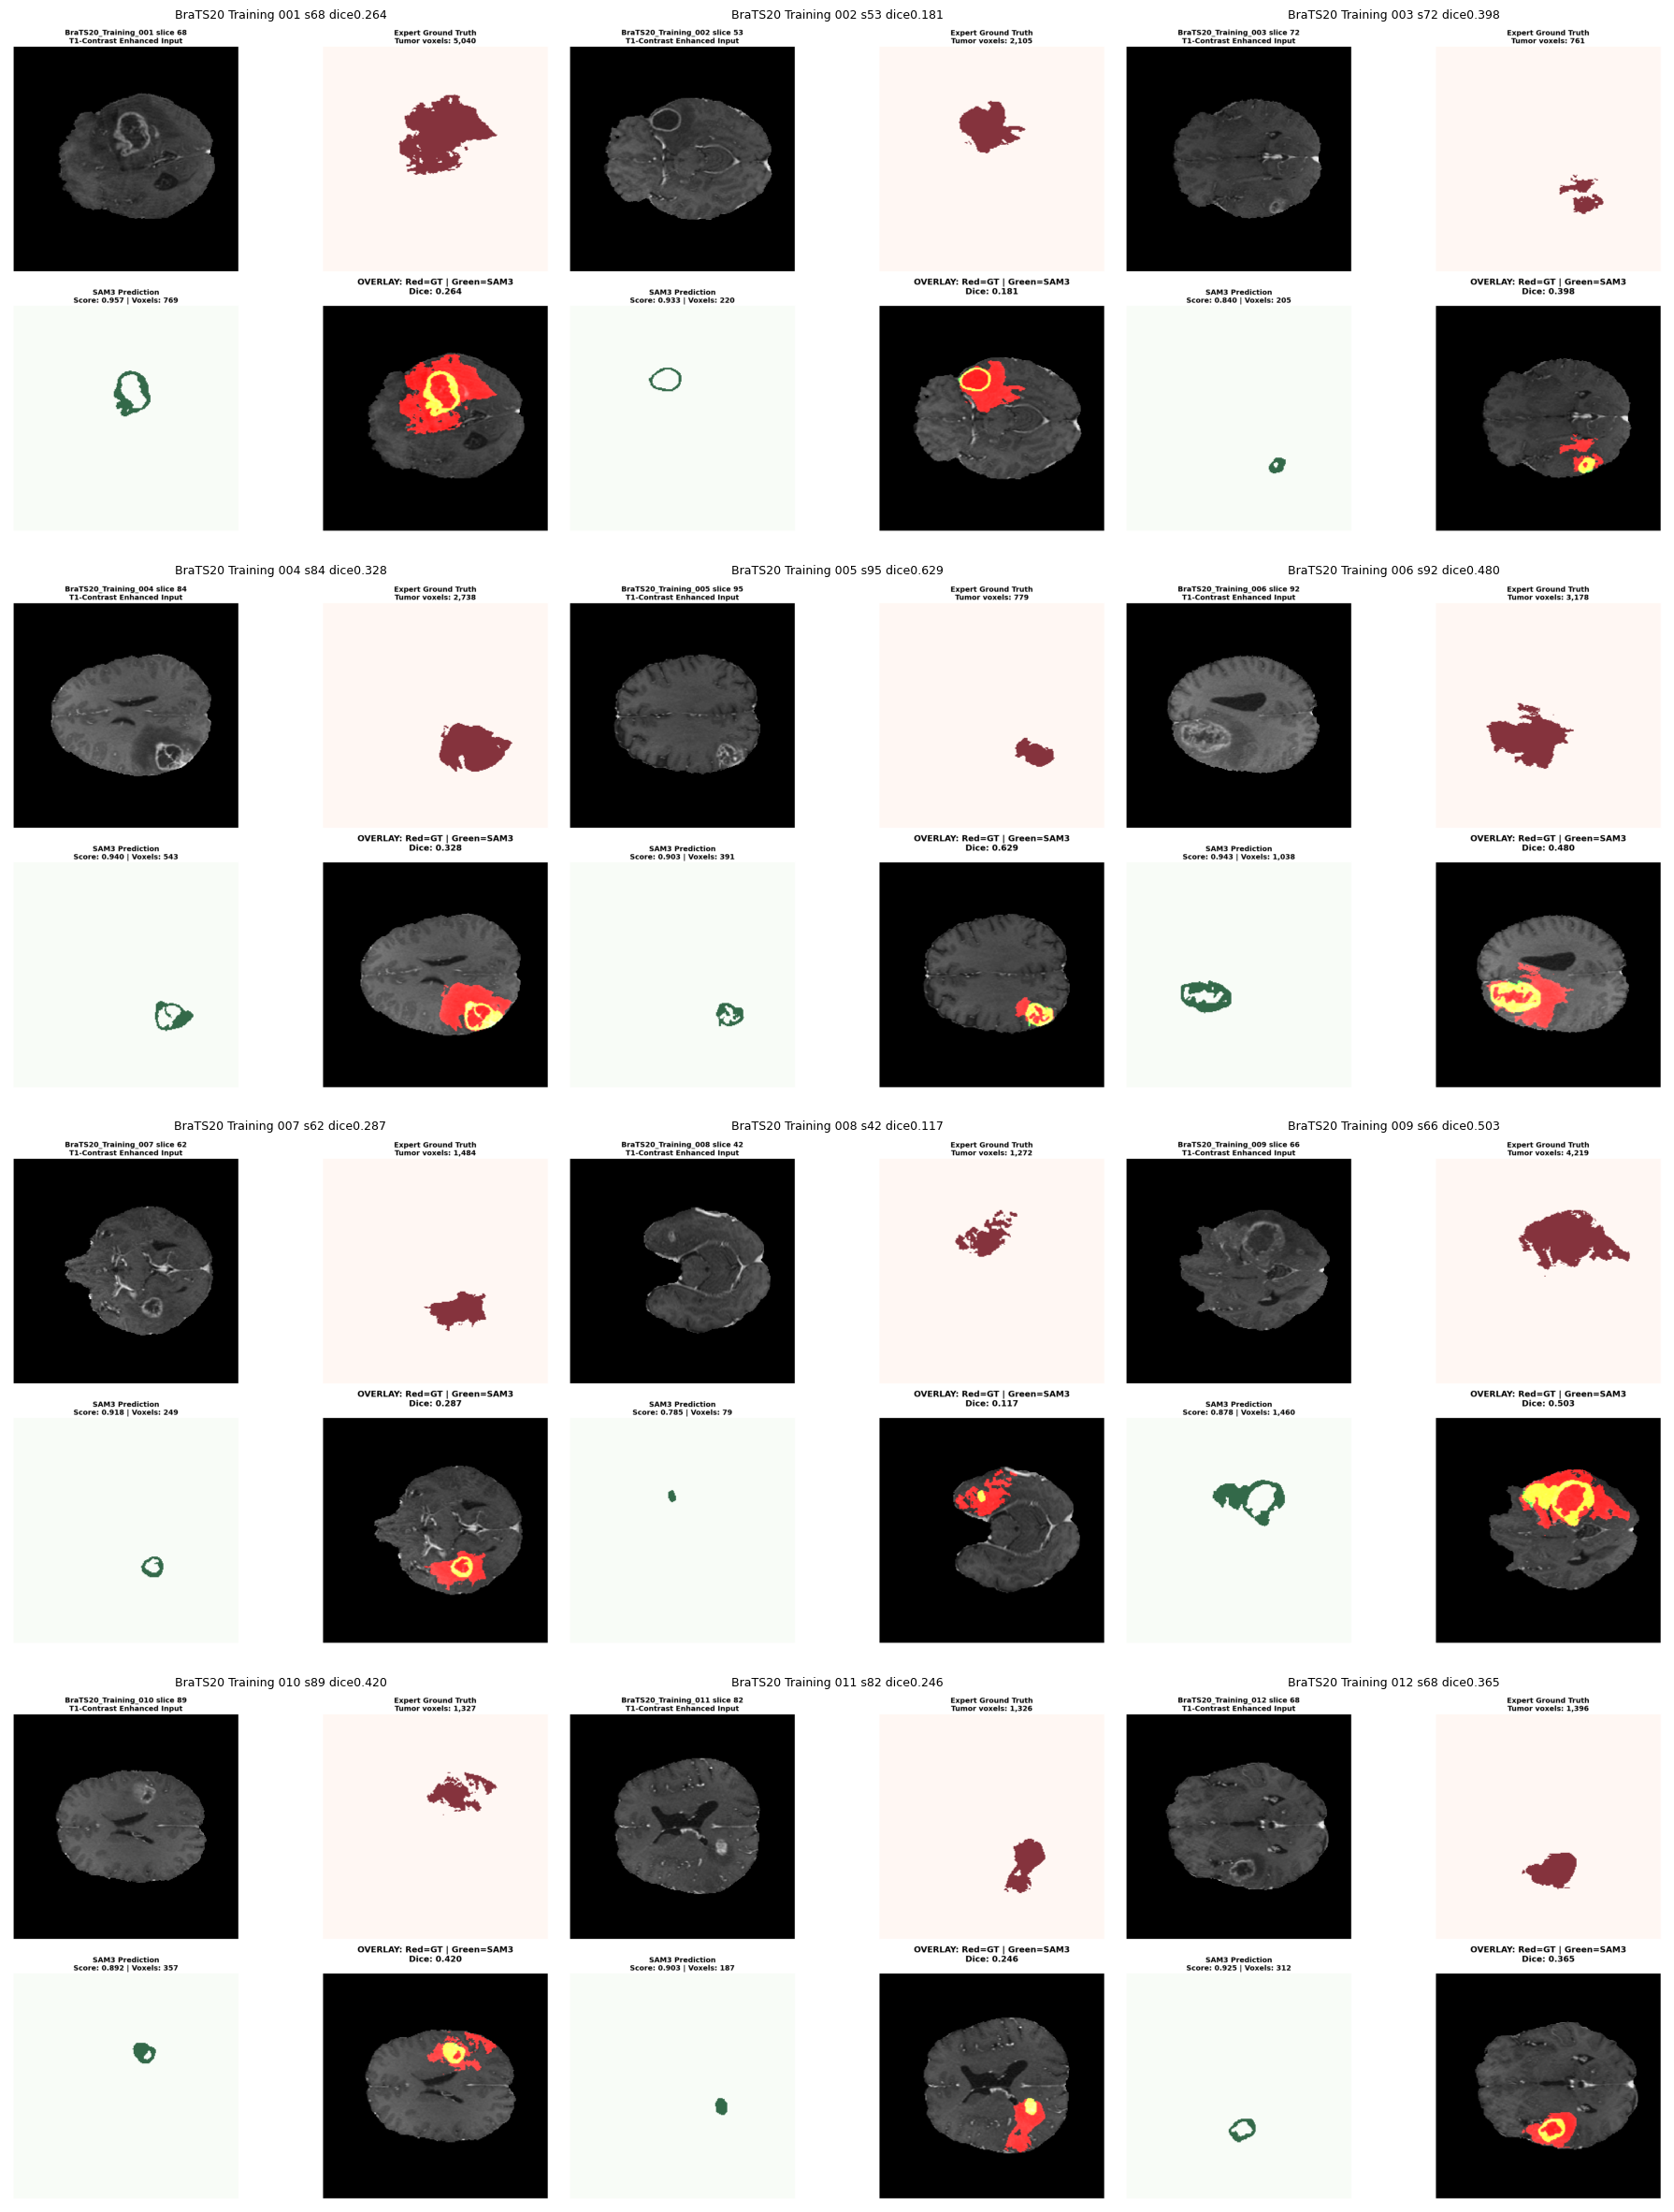


✅ Gallery saved: /content/drive/MyDrive/SAM 3/tumor/plots/brats_gallery.png
✅ Results saved: /content/drive/MyDrive/SAM 3/tumor/plots/brats20_results.csv


In [ ]:
brats_results = evaluate_brats20(processor, max_cases=100)